# Construcción incremental con reducción de dimensionalidad (PCA) previa al agrupamiento

Este experimento es una variante del anterior cuyo objetivo es reducir el coste computacional del agrupamiento. A medida que se acumulan relaciones, cada ejecución de HDBSCAN sobre todo el conocimiento acumulado es más lenta, por lo que aquí se introduce una reducción de dimensionalidad con PCA antes de la clusterización.

El procedimiento tiene dos fases. En una primera fase de calentamiento se recopilan embeddings hasta un mínimo fijado y se entrena un PCA que reduce de 384 a 20 dimensiones; ese PCA se congela. En la segunda fase se repite el proceso incremental, proyectando cada documento con el PCA congelado (solo transformación, sin reajuste) y agrupando con HDBSCAN en el espacio reducido de 20 dimensiones.

El criterio de parada (los cuatro indicadores ortogonales), su agregación en ventana y la fase de rescate del ruido son los mismos que en el experimento anterior. El rescate del ruido se realiza sobre los embeddings originales de 384 dimensiones, ya que la equivalencia semántica se juzga en el espacio completo, no en el reducido.


In [ ]:
# ============================================================
# EXPERIMENTO 10
# Construcción incremental con reducción de dimensionalidad (PCA) previa al agrupamiento
# ============================================================
# En esta celda se centralizan los parámetros principales del
# experimento para que el notebook sea más fácil de reproducir
# y modificar.

# Identificador del experimento.
# Se usará como prefijo en los ficheros de salida.
EXPERIMENTO = "Exp10"

#from google.colab import drive
#drive.mount('/content/drive')

# Carpeta donde se guardarán los resultados generados.
OUTPUT_DIR = "../Output/experiments"

#OUTPUT_DIR = (
#    "/content/drive/MyDrive/TFM/experiments"
#)

# Parámetros principales de HDBSCAN.
# min_cluster_size define el tamaño mínimo que debe tener un cluster.
MIN_CLUSTER_SIZE = 4

# min_samples controla la exigencia del algoritmo para considerar
# un punto como parte de una zona densa.
MIN_SAMPLES = 2

# Semilla para mantener reproducibilidad en aquellos procesos
# que puedan depender de aleatoriedad.
RANDOM_STATE = 42

In [2]:
# ============================================================
# IMPORTS
# ============================================================

import os
import re

import pandas as pd
import numpy as np

import hdbscan

import matplotlib.pyplot as plt


# ============================================================
# CREACIÓN DE CARPETAS DE SALIDA
# ============================================================

# Si la carpeta Outputs no existe, se crea automáticamente.
os.makedirs(OUTPUT_DIR, exist_ok=True)



print("Configuración cargada correctamente.")

Configuración cargada correctamente.


In [3]:
# ============================================================
# LEER DATAFTAME df_sentences DE FICHERO
# 
#  Este punto se ejecuta si se quiere partir de alguna ejecución anterior y no se quieren repetir pasos ya realizados.
# ============================================================

df_triplets = pd.read_pickle(
    "../Output/InformacionAutores10/df_triplets_InformacionAutores10_20260528.pkl"
)

embeddings = np.array(df_triplets["embedding"].tolist())

In [21]:
df_triplets.iloc[6]

id                                                                     40
Nombre                                                   Aburtes, José de
Anyo                                                                 1678
Frase                   Se ahogó en la Barra de Huelva estando en la c...
head                                                           Inés Gallo
head_type                                                             per
tail                                                      Barra de Huelva
tail_type                                                             loc
relation                                                   place of death
head_type_full                                                     person
tail_type_full                                                   location
texto_embedding                            person place of death location
embedding               [0.05328392, -0.0053135627, -0.029121956, -0.0...
translation_relation                  

In [22]:
df_triplets.groupby(["id", "Anyo"]).size()

df_counts = (
    df_triplets
    .groupby(["id", "Anyo"])
    .size()
    .reset_index(name="num_registros")
)

print(f"Número total de textos: {len(df_counts)}")
print(f"Número total de tripletas: {len(df_triplets)}")

Número total de textos: 2374
Número total de tripletas: 27838


In [6]:
# ============================================================
# CLUSTERING SEMÁNTICO TOTAL CON HDBSCAN - Todos los embeddings disponibles
# ============================================================
# Aplicamos HDBSCAN sobre los embeddings generados a partir
# del contexto oracional de cada relación verbal.

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean"
)

clusters = clusterer.fit_predict(embeddings)

# Añadimos los clusters al dataframe.
df_triplets["cluster"] = clusters

print("Clustering completado correctamente.")

# ============================================================
# MÉTRICAS GENERALES
# ============================================================

total_relaciones = len(df_triplets)

# Número de clusters reales (excluyendo ruido = -1)
total_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

# Número de relaciones clasificadas como ruido
total_noise = (clusters == -1).sum()

# Porcentaje de ruido
noise_percentage = round(
    total_noise / total_relaciones * 100,
    2
)

print(f"Relaciones analizadas: {total_relaciones}")
print(f"Clusters detectados: {total_clusters}")
print(f"Relaciones clasificadas como ruido: {total_noise}")
print(f"Porcentaje de ruido: {noise_percentage}%")

Clustering completado correctamente.
Relaciones analizadas: 27838
Clusters detectados: 616
Relaciones clasificadas como ruido: 719
Porcentaje de ruido: 2.58%


### Resumen

Número de textos: 2375

Número de frases: 8782

Relaciones analizadas: 27838

Clusters detectados: 616

Relaciones clasificadas como ruido: 719

Porcentaje de ruido: 2.58%

In [4]:
# ============================================================
# CLUSTERING SEMÁNTICO CON HDBSCAN ITERATIVO + PCA CONGELADO
# CRITERIO ORTOGONAL (4 condiciones) + RESCATE DEL RUIDO
#
# Dos fases:
#   FASE 1 (calentamiento, SIN clustering): recolecta embeddings
#       hasta MIN_EMBEDDINGS_PCA y entrena/congela el PCA (384 -> 20).
#   FASE 2 (clustering iterativo en 20D fijo): reinicia desde cero,
#       proyecta cada grupo con el PCA congelado (solo transform),
#       acumula en 20D y clusteriza con el criterio de parada.
#
# El clustering y las métricas (ARI, degradación, consolidación,
# productividad local) van en el espacio 20D. El RESCATE del ruido
# final se hace sobre los embeddings ORIGINALES 384D normalizados
# (coseno), porque la equivalencia semántica se juzga en el espacio
# completo, no en el reducido.
#
# Criterio de parada (4 condiciones ortogonales):
#   1) productividad local baja   2) ARI alto
#   3) degradación baja (C->N)    4) consolidación baja (N->C)
#
# Umbrales: PROVISIONALES, pendientes de calibración.
# ============================================================

# ------------------------------------------------------------
# REQUISITOS EXTERNOS (definidos previamente en tu entorno):
#   - df_triplets    : DataFrame con columnas ["id", "Anyo", "embedding"]
#                      (embedding = lista/array de floats)
#   - OUTPUT_DIR     : ruta (str) donde escribir log y pickles
#   - MIN_CLUSTER_SIZE : int (min_cluster_size de HDBSCAN)
#   - MIN_SAMPLES      : int (min_samples de HDBSCAN)
# Dependencias: hdbscan, scikit-learn, scipy, joblib, pandas, numpy
# ------------------------------------------------------------

from datetime import datetime
from IPython.display import clear_output
import time
import numpy as np
import pandas as pd
import hdbscan
import joblib
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import radius_neighbors_graph
from scipy.sparse.csgraph import connected_components

MIN_CLUSTER_SIZE = 4
MIN_SAMPLES = 2

# ============================================================
# LOG
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

LOG_FILE = (
    f"{OUTPUT_DIR}/log_mrebel_exp16_pca_ortogonal_{timestamp}.txt"
)

def escribir_log(texto, limpiar=False):

    if limpiar:
        clear_output(wait=True)

    print(texto)

    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(texto + "\n")


def formatear_tiempo(segundos):
    horas = int(segundos // 3600)
    minutos = int((segundos % 3600) // 60)
    segundos = segundos % 60

    return f"{horas:02d}:{minutos:02d}:{segundos:05.2f}"


# ============================================================
# PARÁMETROS DEL EXPERIMENTO
# ============================================================

# Si PARAR=True se aplica el criterio de parada (break) con los
# umbrales actuales. Si PARAR=False, recorre TODO el dataset sin
# parar (útil para generar la pasada completa de calibración).
PARAR = True

VENTANA_PARADA = 30
MIN_EMBEDDINGS_VENTANA = 300

# Productividad máxima permitida de conocimiento nuevo en la ventana.
# 0.04 equivale al 4%.
PRODUCTIVIDAD_CONOCIMIENTO_TOL = 0.0001

# --- Condiciones estructurales nuevas (SÍ deciden la parada) ---
# ARI medio mínimo de la ventana: la estructura debe estar congelada.
# En el run 384D la zona estable tenía ARI medio ~0.99999; 0.99 deja
# margen y bloquea la parada durante la reorganización inicial.
ARI_MIN_TOL = 0.99

# Degradación media máxima de la ventana (cluster -> ruido).
# La zona estable tenía media ~7e-5; 0.005 deja margen y bloquea
# ventanas con disolución sostenida de estructura.
DEGRADACION_MAX_TOL = 0.005

# Consolidación media máxima de la ventana (ruido -> cluster).
# Reemplaza a la antigua movilidad. En el run 384D la media en la
# ventana de parada era ~0.002; 0.01 deja margen. PROVISIONAL: calibrar.
CONSOLIDACION_MAX_TOL = 0.01

# --- Rescate del ruido (fase final, tras la parada) ---
# Tras parar, se intenta agrupar relaciones de ruido entre sí por
# similitud coseno alta (relaciones equivalentes que no llegaron a
# cluster). Las que agrupan reciben un id de cluster nuevo en
# 'cluster_final'; las que no, siguen en -1.
UMBRAL_SIMILITUD = 0.95


# ============================================================
# VARIABLES DE CONTROL
# ============================================================

inicio_total = time.time()

df_triplets_final = pd.DataFrame()
resultados_iteraciones = []

iteration = 0

# Etiquetas completas de la iteración anterior (para ARI y transiciones).
# None hasta la primera ejecución real de HDBSCAN.
clusters_previos = None


# ============================================================
# PROCESAMIENTO ITERATIVO ALEATORIO REPRODUCIBLE
# ============================================================
#
# Las duplas (id, Anyo) no se procesan en el orden original
# del dataset. Antes de iniciar el proceso se genera una
# permutación aleatoria reproducible mediante una semilla fija.
#
# El objetivo es evitar que grupos consecutivos pertenecientes
# al mismo documento o periodo temporal influyan en la creación
# temprana de clusters y en el criterio de parada.
#
# Utilizando siempre la misma semilla se garantiza que el orden
# de procesamiento sea exactamente el mismo entre ejecuciones,
# permitiendo comparar distintas configuraciones experimentales.
#
# ============================================================


RANDOM_STATE = 42

# --- PCA ---
N_COMPONENTS_PCA = 20      # dimensiones tras reducir (384 -> 20)
MIN_EMBEDDINGS_PCA = 5000  # nº mínimo de embeddings para entrenar el PCA (fase 1)

grupos_iteracion = list(
    df_triplets.groupby(["id", "Anyo"])
)

rng = np.random.default_rng(RANDOM_STATE)

orden = rng.permutation(
    len(grupos_iteracion)
)

grupos_iteracion = [
    grupos_iteracion[i]
    for i in orden
]


# ============================================================
# FASE 1: CALENTAMIENTO Y ENTRENAMIENTO DEL PCA (sin clustering)
# ============================================================
#
# Se recorren grupos en el orden fijo y se acumulan embeddings
# hasta MIN_EMBEDDINGS_PCA. Se entrena el PCA una sola vez sobre
# ese lote y se CONGELA. La fase 2 reinicia desde cero sobre el
# MISMO orden y solo aplica pca.transform (nunca reajusta).

escribir_log("=" * 50)
escribir_log("FASE 1: recolección de embeddings para entrenar PCA")
escribir_log("=" * 50)

embeddings_calentamiento = []
n_acumulado_pca = 0
grupos_calentamiento = 0

for (id_value, anyo_value), df_grupo in grupos_iteracion:
    embeddings_calentamiento.append(
        np.array(df_grupo["embedding"].tolist())
    )
    n_acumulado_pca += len(df_grupo)
    grupos_calentamiento += 1
    if n_acumulado_pca >= MIN_EMBEDDINGS_PCA:
        break

X_calentamiento = np.vstack(embeddings_calentamiento)

n_comp = int(min(
    N_COMPONENTS_PCA,
    X_calentamiento.shape[0],
    X_calentamiento.shape[1]
))

if n_acumulado_pca < MIN_EMBEDDINGS_PCA:
    escribir_log(
        f"AVISO: el corpus no alcanza MIN_EMBEDDINGS_PCA={MIN_EMBEDDINGS_PCA}. "
        f"Se entrena PCA con {n_acumulado_pca} embeddings."
    )

pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
pca.fit(X_calentamiento)

var_ratio = pca.explained_variance_ratio_
var_acumulada = float(np.sum(var_ratio))

escribir_log(f"Grupos usados en calentamiento: {grupos_calentamiento}")
escribir_log(f"Embeddings usados en calentamiento: {n_acumulado_pca}")
escribir_log(f"Dimensión original: {X_calentamiento.shape[1]}")
escribir_log(f"Componentes PCA: {n_comp}")
escribir_log(f"Varianza explicada acumulada ({n_comp} comp.): {round(var_acumulada * 100, 2)}%")
escribir_log("Varianza explicada acumulada por nº de componentes:")
for k in (5, 10, 15, 20, 30, 50):
    if k <= n_comp:
        escribir_log(f"  {k:>3} comp -> {round(float(np.sum(var_ratio[:k])) * 100, 2)}%")

joblib.dump(pca, f"{OUTPUT_DIR}/pca_exp16_{timestamp}.joblib")

del embeddings_calentamiento, X_calentamiento
escribir_log("-" * 50)


# ============================================================
# FASE 2: CLUSTERING ITERATIVO EN EL ESPACIO 20D FIJO
# ============================================================

escribir_log("=" * 50)
escribir_log("FASE 2: clustering iterativo (espacio PCA congelado)")
escribir_log("=" * 50)

# acumulado de embeddings ya proyectados a 20D (alineado con df_triplets_final)
embeddings_20d = np.empty((0, n_comp))


for (id_value, anyo_value), df_grupo in grupos_iteracion:

    inicio_iteracion = time.time()
    # Número de relaciones antes de empezar la iteración actual
    relaciones_antes_iteracion = len(df_triplets_final)

    iteration += 1

    # --------------------------------------------------------
    # Añadir nuevas relaciones: proyectar con el PCA CONGELADO
    # (solo transform; el PCA nunca se reajusta)
    # --------------------------------------------------------

    emb_grupo_20 = pca.transform(
        np.array(df_grupo["embedding"].tolist())
    )

    df_triplets_final = pd.concat(
        [df_triplets_final, df_grupo],
        ignore_index=True
    )
    embeddings_20d = np.vstack([embeddings_20d, emb_grupo_20])

    relaciones_anadidas_iteracion = (
        len(df_triplets_final) - relaciones_antes_iteracion
    )


    # --------------------------------------------------------
    # Si todavía no hay suficientes registros
    # --------------------------------------------------------

    # min_cluster_size define el tamaño mínimo que debe tener un cluster.
    if len(df_triplets_final) < MIN_CLUSTER_SIZE:

        df_triplets_final["cluster"] = -1

        fin_iteracion = time.time()

        tiempo_iteracion_segundos = fin_iteracion - inicio_iteracion
        tiempo_total_segundos = fin_iteracion - inicio_total

        tiempo_iteracion = formatear_tiempo(tiempo_iteracion_segundos)
        tiempo_total_acumulado = formatear_tiempo(tiempo_total_segundos)

        escribir_log(f"Iteración: {iteration}", limpiar=True)
        escribir_log(f"Procesando id={id_value}, anyo={anyo_value}")
        escribir_log(f"Relaciones añadidas en la iteración: {relaciones_anadidas_iteracion}")
        escribir_log(f"Relaciones acumuladas: {len(df_triplets_final)}")
        escribir_log(f"Tiempo iteración: {tiempo_iteracion}")
        escribir_log(f"Tiempo total acumulado: {tiempo_total_acumulado}")
        escribir_log("Todavía no hay suficientes registros para ejecutar HDBSCAN")
        escribir_log("-" * 50)

        continue


    # --------------------------------------------------------
    # HDBSCAN
    # --------------------------------------------------------

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        metric="euclidean"
    )

    clusters = clusterer.fit_predict(embeddings_20d)

    df_triplets_final["cluster"] = clusters


    # --------------------------------------------------------
    # MÉTRICAS BÁSICAS
    # --------------------------------------------------------

    # Número total de relaciones (embeddings) procesadas
    total_relaciones = len(df_triplets_final)

    # Número total de agrupaciones obtenidas sin contar el ruido (-1)
    total_clusters = len(set(clusters)) - (
        1 if -1 in clusters else 0
    )

    # Número total de relaciones identificadas como ruido
    total_noise = int((clusters == -1).sum())

    # Porcentaje de ruido respecto al total de relaciones procesadas
    noise_percentage = round(
        total_noise / total_relaciones * 100,
        2
    )

    # Relación ontológica = cluster canónico + ruido individual
    total_relaciones_kg = total_clusters + total_noise

    # Ruido aportado por las relaciones AÑADIDAS en esta iteración
    nuevo_ruido = int(
        (clusters[relaciones_antes_iteracion:] == -1).sum()
    )


    # --------------------------------------------------------
    # MÉTRICAS DE ESTABILIDAD Y MOVIMIENTO (vs iteración anterior)
    # --------------------------------------------------------
    #
    # Se comparan, sobre los puntos ANTIGUOS (presentes en t-1 y en t),
    # las etiquetas previas (clusters_previos) y las actuales
    # (clusters[:relaciones_antes_iteracion]), alineadas por posición.
    #
    # Transiciones posibles por punto antiguo:
    #   C->C : agrupado en ambas  -> reorganización (se mide con ARI)
    #   N->C : ruido -> cluster   -> consolidación
    #   C->N : cluster -> ruido   -> degradación
    #   N->N : sigue siendo ruido -> sin movimiento

    alineado = (
        clusters_previos is not None
        and len(clusters_previos) == relaciones_antes_iteracion
        and relaciones_antes_iteracion >= 1
    )

    if len(resultados_iteraciones) == 0 or not alineado:

        delta_clusters = np.nan
        ruido_a_cluster = np.nan
        cluster_a_ruido = np.nan
        ari_estructura = np.nan
        tasa_consolidacion = np.nan
        tasa_degradacion = np.nan

    else:

        resultado_anterior = resultados_iteraciones[-1]

        # Delta de clusters: SIN truncar (negativo => fusiones). Solo diagnóstico.
        delta_clusters = (
            total_clusters
            - resultado_anterior["total_clusters"]
        )

        # Etiquetas de los puntos antiguos en t-1 y en t (alineadas por posición)
        labels_prev = clusters_previos
        labels_now = clusters[:relaciones_antes_iteracion]

        es_ruido_prev = labels_prev == -1
        es_ruido_now = labels_now == -1

        # --- Reorganización de la estructura estable: ARI solo sobre C->C ---
        mask_cc = (~es_ruido_prev) & (~es_ruido_now)

        if int(mask_cc.sum()) >= 2:
            ari_estructura = float(
                adjusted_rand_score(
                    labels_prev[mask_cc],
                    labels_now[mask_cc]
                )
            )
        else:
            ari_estructura = np.nan

        # --- Movimiento del ruido, por dirección ---
        n_a_c = int((es_ruido_prev & ~es_ruido_now).sum())   # ruido -> cluster
        c_a_n = int((~es_ruido_prev & es_ruido_now).sum())   # cluster -> ruido

        ruido_prev_total = int(es_ruido_prev.sum())
        agrupado_prev_total = int((~es_ruido_prev).sum())

        # Cada dirección normalizada por su "población en riesgo"
        tasa_consolidacion = n_a_c / max(ruido_prev_total, 1)
        tasa_degradacion = c_a_n / max(agrupado_prev_total, 1)

        # Recuentos crudos que explican las tasas (diagnóstico)
        ruido_a_cluster = n_a_c
        cluster_a_ruido = c_a_n





    # --------------------------------------------------------
    # CONOCIMIENTO NUEVO APORTADO POR LA ITERACIÓN  (LOCAL)
    # --------------------------------------------------------
    #
    # Productividad LOCAL de los textos nuevos: de las relaciones
    # AÑADIDAS esta iteración, qué fracción es NO redundante.
    #
    #   - se suma a un cluster que YA existía en t-1  -> REDUNDANTE
    #       (relación canónica que ya teníamos)
    #   - forma parte de un cluster NUEVO             -> útil
    #   - queda como ruido (relación singleton nueva) -> útil
    #
    # conocimiento_nuevo = relaciones nuevas NO redundantes
    #                    = nuevas_en_cluster_nuevo + nuevo_ruido
    #                    = (relaciones añadidas) - (nuevas redundantes)
    #
    # La reorganización de lo VIEJO (divisiones, fusiones, viejo->ruido)
    # NO entra aquí: la cubren los ejes ari_estructura y tasa_degradacion.

    labels_new = clusters[relaciones_antes_iteracion:]   # etiquetas de las relaciones nuevas

    if alineado:
        labels_old = clusters[:relaciones_antes_iteracion]
        # clusters que YA existían en t-1: contienen algún punto viejo
        # que ya estaba agrupado (no era ruido) en t-1
        clusters_preexistentes = set(
            labels_old[clusters_previos != -1].tolist()
        ) - {-1}
    else:
        clusters_preexistentes = set()

    if clusters_preexistentes:
        mask_redundante = (labels_new != -1) & np.isin(
            labels_new, list(clusters_preexistentes)
        )
    else:
        mask_redundante = np.zeros(len(labels_new), dtype=bool)

    nuevas_redundantes = int(mask_redundante.sum())
    nuevas_en_cluster_nuevo = int(
        len(labels_new) - nuevo_ruido - nuevas_redundantes
    )

    conocimiento_nuevo_iteracion = (
        nuevas_en_cluster_nuevo + nuevo_ruido
    )

    ratio_conocimiento_nuevo_iteracion = (
        conocimiento_nuevo_iteracion
        / max(relaciones_anadidas_iteracion, 1)
    )

    # Guardar etiquetas actuales como referencia para la próxima iteración
    clusters_previos = clusters.copy()



    # --------------------------------------------------------
    # TIEMPOS DE ITERACIÓN
    # --------------------------------------------------------

    fin_iteracion = time.time()

    tiempo_iteracion_segundos = fin_iteracion - inicio_iteracion
    tiempo_total_segundos = fin_iteracion - inicio_total

    tiempo_iteracion = formatear_tiempo(tiempo_iteracion_segundos)
    tiempo_total_acumulado = formatear_tiempo(tiempo_total_segundos)


    # --------------------------------------------------------
    # GUARDAR RESULTADOS DE ITERACIÓN
    # --------------------------------------------------------

    resultados_iteraciones.append({
        "iteration": iteration,
        "id": id_value,
        "anyo": anyo_value,

        "total_relaciones": total_relaciones,
        "total_clusters": total_clusters,
        "total_noise": total_noise,
        "noise_percentage": noise_percentage,
        "total_relaciones_kg": total_relaciones_kg,

        "nuevos_embeddings": len(df_grupo),
        "relaciones_anadidas_iteracion": relaciones_anadidas_iteracion,

        "delta_clusters": delta_clusters,
        "nuevo_ruido": nuevo_ruido,
        "nuevas_redundantes": nuevas_redundantes,
        "nuevas_en_cluster_nuevo": nuevas_en_cluster_nuevo,
        "conocimiento_nuevo_iteracion": conocimiento_nuevo_iteracion,
        "ratio_conocimiento_nuevo_iteracion": ratio_conocimiento_nuevo_iteracion,

        "ruido_a_cluster": ruido_a_cluster,
        "cluster_a_ruido": cluster_a_ruido,

        "ari_estructura": ari_estructura,
        "tasa_consolidacion": tasa_consolidacion,
        "tasa_degradacion": tasa_degradacion,

        "tiempo_iteracion_segundos": tiempo_iteracion_segundos,
        "tiempo_iteracion": tiempo_iteracion,
        "tiempo_total_segundos": tiempo_total_segundos,
        "tiempo_total_acumulado": tiempo_total_acumulado
    })


    # --------------------------------------------------------
    # LOG DE ITERACIÓN
    # --------------------------------------------------------

    escribir_log(f"Iteración: {iteration}", limpiar=True)
    escribir_log(f"Procesando id={id_value}, anyo={anyo_value}")
    escribir_log(f"Relaciones añadidas en la iteración: {relaciones_anadidas_iteracion}")
    escribir_log(f"Relaciones acumuladas: {total_relaciones}")
    escribir_log(f"Clusters detectados: {total_clusters}")
    escribir_log(f"Delta clusters (sin truncar): {delta_clusters}")
    escribir_log(f"Relaciones clasificadas como ruido: {total_noise}")
    escribir_log(f"Porcentaje de ruido: {noise_percentage}%")
    escribir_log(f"Relaciones finales KG: {total_relaciones_kg}")
    escribir_log(f"Nuevas en cluster nuevo: {nuevas_en_cluster_nuevo}")
    escribir_log(f"Nuevas redundantes (cluster ya existente): {nuevas_redundantes}")
    escribir_log(f"Nuevo ruido: {nuevo_ruido}")
    escribir_log(f"Conocimiento nuevo iteración (no redundante): {conocimiento_nuevo_iteracion}")
    escribir_log(f"Ratio conocimiento nuevo iteración: {ratio_conocimiento_nuevo_iteracion}")
    escribir_log(f"Ruido a cluster (N->C): {ruido_a_cluster}")
    escribir_log(f"Cluster a ruido (C->N): {cluster_a_ruido}")
    escribir_log(f"[diag] Delta clusters (sin truncar): {delta_clusters}")
    escribir_log(f"ARI estructura (C->C): {ari_estructura}")
    escribir_log(f"Tasa consolidación (N->C): {tasa_consolidacion}")
    escribir_log(f"Tasa degradación (C->N): {tasa_degradacion}")
    escribir_log(f"Tiempo iteración: {tiempo_iteracion}")
    escribir_log(f"Tiempo total acumulado: {tiempo_total_acumulado}")
    escribir_log("-" * 50)


    # ========================================================
    # CRITERIO DE PARADA  (umbrales actuales, sin cambios)
    # ========================================================

    if len(resultados_iteraciones) >= VENTANA_PARADA:

        ultimas_iteraciones = resultados_iteraciones[-VENTANA_PARADA:]

        embeddings_ventana = sum(
            item["nuevos_embeddings"]
            for item in ultimas_iteraciones
        )

        conocimiento_nuevo_ventana = sum(
            item["conocimiento_nuevo_iteracion"]
            for item in ultimas_iteraciones
        )

        ratio_productividad_conocimiento_ventana = (
            conocimiento_nuevo_ventana
            / max(embeddings_ventana, 1)
        )

        conocimiento_nuevo_bajo = (
            ratio_productividad_conocimiento_ventana
            <= PRODUCTIVIDAD_CONOCIMIENTO_TOL
        )

        # --- Medias de las métricas estructurales en la ventana ---
        valores_ari = [
            item["ari_estructura"]
            for item in ultimas_iteraciones
            if not pd.isna(item["ari_estructura"])
        ]
        media_ari_estructura = np.mean(valores_ari) if valores_ari else np.nan

        valores_consolidacion = [
            item["tasa_consolidacion"]
            for item in ultimas_iteraciones
            if not pd.isna(item["tasa_consolidacion"])
        ]
        media_tasa_consolidacion = (
            np.mean(valores_consolidacion) if valores_consolidacion else np.nan
        )

        valores_degradacion = [
            item["tasa_degradacion"]
            for item in ultimas_iteraciones
            if not pd.isna(item["tasa_degradacion"])
        ]
        media_tasa_degradacion = (
            np.mean(valores_degradacion) if valores_degradacion else np.nan
        )

        # --- Condiciones estructurales que SÍ deciden la parada ---
        # NaN => no se puede confirmar estabilidad => no se permite parar.
        ari_estructura_estable = (
            (not pd.isna(media_ari_estructura))
            and (media_ari_estructura >= ARI_MIN_TOL)
        )
        degradacion_baja = (
            (not pd.isna(media_tasa_degradacion))
            and (media_tasa_degradacion <= DEGRADACION_MAX_TOL)
        )
        # Consolidación (N->C): el ruido todavía se organiza en estructura.
        # Reemplaza a movilidad_ruido_baja (mejor normalizada y por dirección).
        consolidacion_baja = (
            (not pd.isna(media_tasa_consolidacion))
            and (media_tasa_consolidacion <= CONSOLIDACION_MAX_TOL)
        )

        resultados_iteraciones[-1]["embeddings_ventana"] = embeddings_ventana
        resultados_iteraciones[-1]["conocimiento_nuevo_ventana"] = conocimiento_nuevo_ventana
        resultados_iteraciones[-1]["ratio_productividad_conocimiento_ventana"] = ratio_productividad_conocimiento_ventana
        resultados_iteraciones[-1]["conocimiento_nuevo_bajo"] = conocimiento_nuevo_bajo

        resultados_iteraciones[-1]["media_ari_estructura"] = media_ari_estructura
        resultados_iteraciones[-1]["media_tasa_consolidacion"] = media_tasa_consolidacion
        resultados_iteraciones[-1]["media_tasa_degradacion"] = media_tasa_degradacion
        resultados_iteraciones[-1]["ari_estructura_estable"] = ari_estructura_estable
        resultados_iteraciones[-1]["degradacion_baja"] = degradacion_baja
        resultados_iteraciones[-1]["consolidacion_baja"] = consolidacion_baja

        escribir_log(f"Embeddings ventana: {embeddings_ventana}")
        escribir_log(f"Conocimiento nuevo ventana: {conocimiento_nuevo_ventana}")
        escribir_log(f"Ratio productividad conocimiento ventana: {ratio_productividad_conocimiento_ventana}")
        escribir_log(f"Conocimiento nuevo bajo: {conocimiento_nuevo_bajo}")
        escribir_log(f"Media ARI estructura: {media_ari_estructura}")
        escribir_log(f"ARI estructura estable: {ari_estructura_estable}")
        escribir_log(f"Media tasa degradación: {media_tasa_degradacion}")
        escribir_log(f"Degradación baja: {degradacion_baja}")
        escribir_log(f"Media tasa consolidación: {media_tasa_consolidacion}")
        escribir_log(f"Consolidación baja: {consolidacion_baja}")
        escribir_log("-" * 50)

        if (
            PARAR
            and embeddings_ventana >= MIN_EMBEDDINGS_VENTANA
            and conocimiento_nuevo_bajo
            and ari_estructura_estable
            and degradacion_baja
            and consolidacion_baja
        ):

            escribir_log("Criterio de parada alcanzado.")
            escribir_log(
                "Motivo: baja productividad local de textos nuevos, estructura "
                "estable (ARI alto), baja degradación (cluster->ruido) y baja "
                "consolidación (ruido->cluster)."
            )
            break


# ============================================================
# FASE DE RESCATE DEL RUIDO (post-parada)
# ============================================================
#
# Sobre las relaciones que quedaron como ruido (-1), se buscan
# grupos de relaciones EQUIVALENTES por similitud coseno alta
# (>= UMBRAL_SIMILITUD), usando los embeddings ORIGINALES de 384D
# (normalizados). Las componentes conexas de tamaño >= 2 reciben
# un id de cluster nuevo (a partir de max(cluster)+1) en la columna
# 'cluster_final'. El resto se queda en -1.
#
# 'cluster' se conserva intacto; 'cluster_final' es la etiqueta
# definitiva para construir el KG (extracción de medoides).

escribir_log("=" * 50)
escribir_log("FASE DE RESCATE DEL RUIDO")
escribir_log("=" * 50)

cluster_final = df_triplets_final["cluster"].to_numpy().copy()
ruido_mask = cluster_final == -1
idx_ruido = np.where(ruido_mask)[0]

nuevos_clusters_rescate = 0
relaciones_rescatadas = 0

if len(idx_ruido) >= 2:

    E_ruido = np.array(
        df_triplets_final.loc[ruido_mask, "embedding"].tolist()
    )

    # Grafo de vecinos: distancia coseno <= (1 - umbral)  <=>  similitud >= umbral
    grafo = radius_neighbors_graph(
        E_ruido,
        radius=1.0 - UMBRAL_SIMILITUD,
        metric="cosine",
        include_self=False,
        mode="connectivity"
    )

    n_comp, etiquetas_comp = connected_components(grafo, directed=False)

    siguiente_id = int(cluster_final.max()) + 1 if cluster_final.max() >= 0 else 0

    for c in range(n_comp):
        miembros = idx_ruido[etiquetas_comp == c]
        if len(miembros) >= 2:
            cluster_final[miembros] = siguiente_id
            siguiente_id += 1
            nuevos_clusters_rescate += 1
            relaciones_rescatadas += len(miembros)

df_triplets_final["cluster_final"] = cluster_final

# Métricas del KG tras el rescate
ruido_final = int((cluster_final == -1).sum())
clusters_final_total = len(set(cluster_final.tolist())) - (1 if -1 in cluster_final else 0)
total_relaciones_kg_final = clusters_final_total + ruido_final

escribir_log(f"Umbral de similitud: {UMBRAL_SIMILITUD}")
escribir_log(f"Relaciones de ruido antes del rescate: {len(idx_ruido)}")
escribir_log(f"Nuevos clusters rescatados: {nuevos_clusters_rescate}")
escribir_log(f"Relaciones rescatadas (dejaron de ser ruido): {relaciones_rescatadas}")
escribir_log(f"Ruido final: {ruido_final}")
escribir_log(f"Clusters finales (original + rescate): {clusters_final_total}")
escribir_log(f"Relaciones finales KG (cluster_final): {total_relaciones_kg_final}")
escribir_log("-" * 50)


# ============================================================
# GUARDADO DE RESULTADOS
# ============================================================

df_resultados_iteraciones = pd.DataFrame(resultados_iteraciones)

df_triplets_final.to_pickle(
    f"{OUTPUT_DIR}/df_triplets_final_exp16_pca_ortogonal_{timestamp}.pkl"
)

df_resultados_iteraciones.to_pickle(
    f"{OUTPUT_DIR}/df_resultados_iteraciones_exp16_pca_ortogonal_{timestamp}.pkl"
)


# ============================================================
# RESUMEN FINAL
# ============================================================

escribir_log("Proceso finalizado.")
escribir_log(f"Log guardado en: {LOG_FILE}")
escribir_log(f"Iteraciones ejecutadas: {iteration}")
escribir_log(f"Relaciones finales acumuladas: {len(df_triplets_final)}")
escribir_log(f"Clusters detectados (antes del rescate): {total_clusters}")
escribir_log(f"Relaciones clasificadas como ruido (antes del rescate): {total_noise}")
escribir_log(f"Porcentaje de ruido: {noise_percentage}%")
escribir_log(f"Relaciones finales KG (antes del rescate): {total_relaciones_kg}")
escribir_log(f"--- Tras el rescate del ruido ---")
escribir_log(f"Clusters finales: {clusters_final_total}")
escribir_log(f"Ruido final: {ruido_final}")
escribir_log(f"Relaciones finales KG (cluster_final): {total_relaciones_kg_final}")

fin_total = time.time()
tiempo_total = fin_total - inicio_total

minutos_total = int(tiempo_total // 60)
segundos_total = tiempo_total % 60

print(f"Tiempo de ejecución total: {minutos_total} min {segundos_total:.2f} s")

Iteración: 2374
Procesando id=2877, anyo=1606
Relaciones añadidas en la iteración: 6
Relaciones acumuladas: 27838
Clusters detectados: 779
Delta clusters (sin truncar): 0
Relaciones clasificadas como ruido: 740
Porcentaje de ruido: 2.66%
Relaciones finales KG: 1519
Nuevas en cluster nuevo: 0
Nuevas redundantes (cluster ya existente): 5
Nuevo ruido: 1
Conocimiento nuevo iteración (no redundante): 1
Ratio conocimiento nuevo iteración: 0.16666666666666666
Ruido a cluster (N->C): 4
Cluster a ruido (C->N): 7
[diag] Delta clusters (sin truncar): 0
ARI estructura (C->C): 0.9999981980651212
Tasa consolidación (N->C): 0.005434782608695652
Tasa degradación (C->N): 0.00025834071449660465
Tiempo iteración: 00:00:02.80
Tiempo total acumulado: 01:16:44.08
--------------------------------------------------
Embeddings ventana: 316
Conocimiento nuevo ventana: 13
Ratio productividad conocimiento ventana: 0.04113924050632911
Conocimiento nuevo bajo: False
Media ARI estructura: 0.9999518405203572
ARI estr

In [ ]:
# ============================================================
# LEER DATAFTAME df_sentences DE FICHERO
# 
#  Este punto se ejecuta si se quiere partir de alguna ejecución anterior y no se quieren repetir pasos ya realizados.
# ============================================================

df_resultados_iteraciones = pd.read_pickle(
    "../Output/experiments/df_resultados_iteraciones_exp16_pca_ortogonal_20260629_172044.pkl"
)

Figura guardada en: trayectoria_metricas.png  (4 paneles, mostrar='ambas')


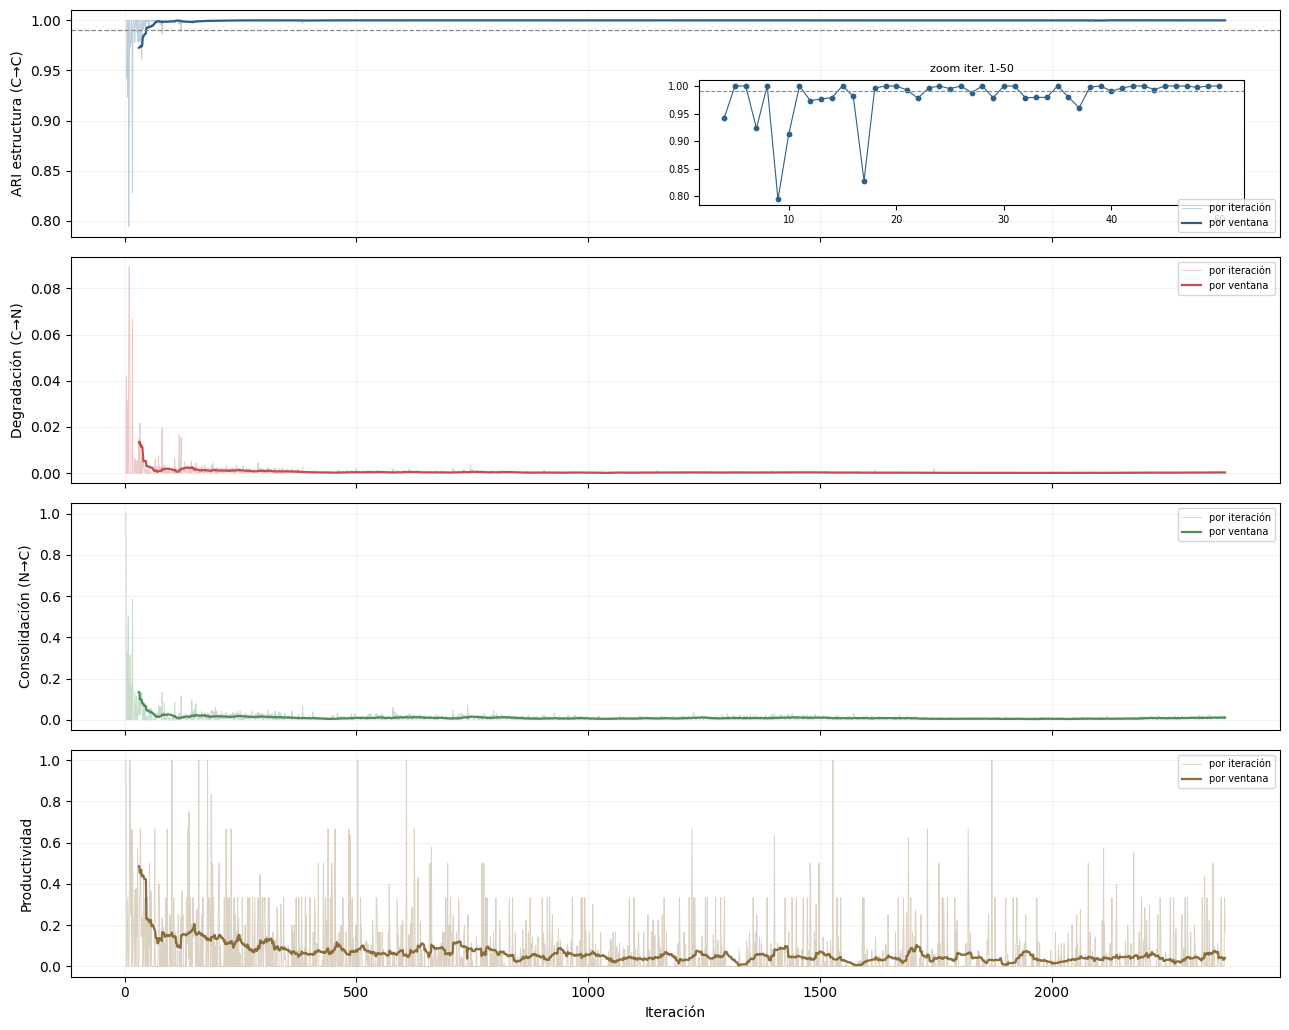

In [7]:
"""
Trayectoria de las métricas del criterio de parada, a partir del dataframe de
resultados por iteración.

Cada métrica existe en dos formas en el dataframe:
  - por ITERACIÓN: la señal cruda de cada paso.
  - por VENTANA  : la media móvil, que es la que usa la decisión de parada.

Por defecto se muestran ambas: la de iteración tenue y la de ventana gruesa.
Con `mostrar="ventana"` o `mostrar="iteracion"` se enseña solo una.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Configuración
# ---------------------------------------------------------------------------
ARI_UMBRAL = 0.99          # umbral de referencia que se dibuja en el panel ARI
ZOOM_MAX = 50              # rango de iteraciones del recuadro de zoom (panel ARI)
DELTA_YLIM = (-3, 6)       # recorte vertical del panel de delta de clusters
OUTPUT_PATH = "trayectoria_metricas.png"   # imagen de salida (None = no guardar)

COL_ITER = "iteration"

# Especificación de las métricas a dibujar: (etiqueta, col_iteracion, col_ventana,
# tipo, color). col_ventana=None -> la métrica no tiene forma de ventana.
METRICAS = [
    ("ARI estructura (C→C)",  "ari_estructura",                     "media_ari_estructura",                     "linea",  "#2c5f8a"),
    ("Degradación (C→N)",     "tasa_degradacion",                   "media_tasa_degradacion",                   "linea",  "#c0504d"),
    ("Consolidación (N→C)",   "tasa_consolidacion",                 "media_tasa_consolidacion",                 "linea",  "#4e8c5a"),
    ("Productividad",         "ratio_conocimiento_nuevo_iteracion", "ratio_productividad_conocimiento_ventana", "linea",  "#8a6d3b"),
]


def _panel_linea(ax, df, col_iter, col_vent, color, mostrar):
    if mostrar in ("ambas", "iteracion") and col_iter in df:
        ax.plot(df[COL_ITER], df[col_iter], lw=0.7, color=color,
                alpha=0.30 if mostrar == "ambas" else 0.9,
                label="por iteración")
    if mostrar in ("ambas", "ventana") and col_vent and col_vent in df:
        ax.plot(df[COL_ITER], df[col_vent], lw=1.6, color=color,
                label="por ventana")
    if mostrar == "ambas" and col_vent:
        ax.legend(fontsize=7, loc="best")


def _panel_barras(ax, df, col_iter, color):
    d = df.dropna(subset=[col_iter])
    colores = np.where(d[col_iter] >= 0, color, "#b94a48")
    ax.bar(d[COL_ITER], d[col_iter], width=1.0, color=colores)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylim(*DELTA_YLIM)


def _zoom_ari(ax, df, color):
    axz = ax.inset_axes([0.52, 0.14, 0.45, 0.55])
    dz = df[df[COL_ITER] <= ZOOM_MAX]
    axz.plot(dz[COL_ITER], dz["ari_estructura"], lw=0.8, color=color)
    axz.scatter(dz[COL_ITER], dz["ari_estructura"], s=10, color=color)
    axz.axhline(ARI_UMBRAL, ls="--", lw=0.8, color="#888")
    axz.set_title(f"zoom iter. 1-{ZOOM_MAX}", fontsize=8)
    axz.tick_params(labelsize=7)


def graficar_trayectoria_metricas(df, mostrar="ambas", output_path=OUTPUT_PATH,
                                  metricas=METRICAS):

    df = df.sort_values(COL_ITER).reset_index(drop=True)

    metricas = [m for m in metricas if m[1] in df.columns]
    n = len(metricas)
    fig, axes = plt.subplots(n, 1, figsize=(13, 2.6 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, (etq, col_it, col_vt, tipo, color) in zip(axes, metricas):
        if tipo == "barras":
            _panel_barras(ax, df, col_it, color)
        else:
            _panel_linea(ax, df, col_it, col_vt, color, mostrar)
            if col_it == "ari_estructura":
                ax.axhline(ARI_UMBRAL, ls="--", lw=0.9, color="#888")
                _zoom_ari(ax, df, color)
        ax.set_ylabel(etq)
        ax.grid(alpha=0.15)

    axes[-1].set_xlabel("Iteración")
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=130, bbox_inches="tight")
        print(f"Figura guardada en: {output_path}  ({n} paneles, mostrar='{mostrar}')")
    return fig


fig = graficar_trayectoria_metricas(df_resultados_iteraciones)
plt.show()

In [14]:
"""
Comparación del agrupamiento con PCA (20D) frente al agrupamiento sin PCA (384D)
mediante el índice de Rand ajustado (ARI).

El dataframe del run con PCA ya contiene:
  - "cluster"   : etiqueta del agrupamiento en el espacio reducido (20D)
  - "embedding" : embedding original de 384 dimensiones

Para que la comparación sea exacta, el agrupamiento sin PCA se reproduce aquí
sobre esos mismos embeddings de 384D, con los mismos parámetros de HDBSCAN.
Así ambas particiones quedan alineadas relación a relación por el índice.
"""

import numpy as np
import pandas as pd
import hdbscan
from sklearn.metrics import adjusted_rand_score

MIN_CLUSTER_SIZE = 4
MIN_SAMPLES = 2

# 1. Cargar el dataframe del run con PCA y fijar el orden de filas
df = pd.read_pickle(
    f"../Output/experiments/df_triplets_final_exp16_pca_ortogonal_20260629_172044.pkl"
).reset_index(drop=True)

# Agrupamiento CON PCA (ya calculado en el run, espacio de 20 dimensiones)
cluster_pca = df["cluster"].to_numpy()

# 2. Reproducir el agrupamiento SIN PCA sobre los embeddings de 384 dimensiones
embeddings_384 = np.array(df["embedding"].tolist())

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean"
)
cluster_sinpca = clusterer.fit_predict(embeddings_384)

# 3. Recuento de grupos y ruido en cada agrupamiento
def resumen(etiquetas, nombre):
    grupos = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
    ruido = int((etiquetas == -1).sum())
    print(f"{nombre}: grupos={grupos}, ruido={ruido} "
          f"({100*ruido/len(etiquetas):.2f}%)")

resumen(cluster_sinpca, "Sin PCA (384D)")
resumen(cluster_pca, "Con PCA (20D)")

# 4. ARI sobre TODAS las relaciones (el ruido -1 cuenta como una categoría más)
ari_total = adjusted_rand_score(cluster_sinpca, cluster_pca)
print(f"\nARI (todas las relaciones): {ari_total:.4f}")

# 5. ARI solo sobre las relaciones agrupadas en AMBOS (excluye el ruido de cualquiera)
mask = (cluster_sinpca != -1) & (cluster_pca != -1)
ari_agrupadas = adjusted_rand_score(cluster_sinpca[mask], cluster_pca[mask])
print(f"Relaciones agrupadas en ambos: {int(mask.sum())}")
print(f"ARI (solo agrupadas en ambos): {ari_agrupadas:.4f}")

# Guardar ambas particiones como columnas para los análisis posteriores
df["c_sin"] = cluster_sinpca
df["c_pca"] = cluster_pca

Sin PCA (384D): grupos=616, ruido=719 (2.58%)
Con PCA (20D): grupos=779, ruido=740 (2.66%)

ARI (todas las relaciones): 0.8387
Relaciones agrupadas en ambos: 26881
ARI (solo agrupadas en ambos): 0.8530


In [15]:
# ------------------------------------------------------------
# Ejemplo de fragmentación por PCA: un grupo del espacio de 384
# dimensiones que, al reducir a 20, se reparte en varios grupos,
# incluso entre relaciones que comparten un vector idéntico.
# (requiere df con las columnas "c_sin" y "c_pca" del paso anterior)
# ------------------------------------------------------------
import numpy as np

# Localizar el grupo sin PCA que más se fragmenta entre relaciones de vector repetido
GRUPO_SIN_PCA = 15   # ajusta si tu numeración difiere; es el de "elevation above sea level"

sub = df[df["c_sin"] == GRUPO_SIN_PCA]
print(f"Grupo sin PCA {GRUPO_SIN_PCA}: {len(sub)} relaciones, "
      f"{sub['c_pca'].nunique()} etiquetas distintas con PCA")
print(f"Vectores distintos en el grupo: {sub['texto_embedding'].nunique()}")
print()

# Reparto de esas relaciones entre los grupos que crea el PCA
for etq_pca, s in sub.groupby("c_pca"):
    destino = "ruido" if etq_pca == -1 else f"grupo PCA {etq_pca}"
    rel = s["relation"].iloc[0]
    print(f"  {destino}: {len(s)} relaciones (relación '{rel}')")

# Comprobación de que hay vectores idénticos repartidos en grupos distintos
import itertools
etqs = [e for e in sub["c_pca"].unique() if e != -1]
for a, b in itertools.combinations(etqs, 2):
    va = np.array(sub[sub.c_pca == a]["embedding"].tolist())
    vb = np.array(sub[sub.c_pca == b]["embedding"].tolist())
    if np.allclose(va[0], vb[0]):
        print(f"\n  Los grupos PCA {a} y {b} contienen un vector idéntico "
              f"(distancia {np.linalg.norm(va[0]-vb[0]):.4f}).")

Grupo sin PCA 15: 26 relaciones, 4 etiquetas distintas con PCA
Vectores distintos en el grupo: 2

  ruido: 3 relaciones (relación 'elevation above sea level')
  grupo PCA 464: 1 relaciones (relación 'elevation above sea level')
  grupo PCA 468: 5 relaciones (relación 'elevation above sea level')
  grupo PCA 469: 17 relaciones (relación 'elevation above sea level')

  Los grupos PCA 468 y 469 contienen un vector idéntico (distancia 0.0000).


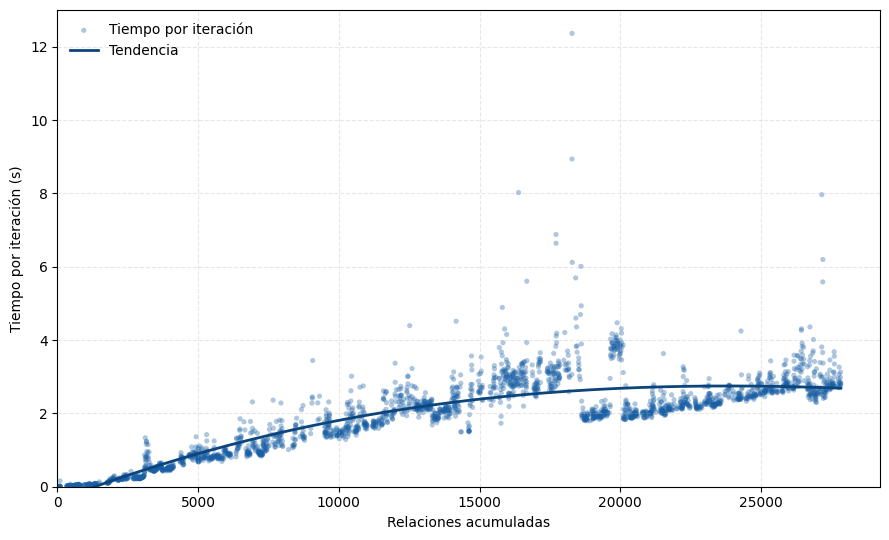

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el dataframe de resultados por iteración
df = pd.read_pickle("../Output/experiments/df_resultados_iteraciones_exp16_pca_ortogonal_20260629_172044.pkl")

# 2. Quedarse con las iteraciones que tienen tiempo medido y ordenarlas
val = df.dropna(subset=["tiempo_iteracion_segundos"]).sort_values("total_relaciones")

x = val["total_relaciones"].to_numpy()
y = val["tiempo_iteracion_segundos"].to_numpy()

# 3. Curva de ajuste: polinomio de grado 3 sobre la nube de puntos
coef = np.polyfit(x, y, deg=3)
x_linea = np.linspace(x.min(), x.max(), 200)
y_linea = np.polyval(coef, x_linea)

# 4. Dibujar
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(x, y, s=14, color="#185FA5", alpha=0.35, edgecolors="none",
           label="Tiempo por iteración")
ax.plot(x_linea, y_linea, color="#0C447C", linewidth=2,
        label="Tendencia")

ax.set_xlabel("Relaciones acumuladas")
ax.set_ylabel("Tiempo por iteración (s)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="upper left", frameon=False)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("exp6_coste_computacional.png", dpi=300, bbox_inches="tight")
plt.savefig("exp6_coste_computacional.svg", bbox_inches="tight")
plt.show()

In [19]:
import pandas as pd
import numpy as np

# Cargar los dos dataframes de iteraciones
pca = pd.read_pickle(
    f"../Output/experiments/df_resultados_iteraciones_exp16_pca_ortogonal_20260629_172044.pkl"
)
sin = pd.read_pickle(
    f"../Output/experiments/df_resultados_iteraciones_exp09_ortogonal_sinpca_20260628_191456.pkl"
)

# Quedarse con las iteraciones que tienen tiempo de agrupamiento medido
pca_v = pca.dropna(subset=["tiempo_iteracion_segundos"])
sin_v = sin.dropna(subset=["tiempo_iteracion_segundos"])

# Tramos de relaciones acumuladas a comparar
tramos = [(0, 1000), (1000, 2000), (2000, 3000),
          (3000, 4000), (4000, 5000), (5000, 6400)]

filas = []
for lo, hi in tramos:
    s = sin_v[(sin_v["total_relaciones"] >= lo) &
              (sin_v["total_relaciones"] < hi)]["tiempo_iteracion_segundos"]
    p = pca_v[(pca_v["total_relaciones"] >= lo) &
              (pca_v["total_relaciones"] < hi)]["tiempo_iteracion_segundos"]
    if len(s) and len(p):
        t_sin = s.mean()
        t_pca = p.mean()
        factor = t_sin / t_pca
        filas.append({
            "Relaciones acumuladas": f"{lo} - {hi}",
            "Sin PCA (s)": round(t_sin, 2),
            "Con PCA (s)": round(t_pca, 2),
            "Factor exacto": round(factor, 1),
            "Factor redondeado": f"{round(factor)}x"
        })

tabla = pd.DataFrame(filas)
print(tabla.to_string(index=False))

# Resumen global (para el texto)
print()
print(f"Sin PCA: hasta {int(sin_v['total_relaciones'].max())} relaciones, "
      f"{sin['tiempo_total_segundos'].iloc[-1]/60:.1f} min")
print(f"Con PCA: hasta {int(pca_v['total_relaciones'].max())} relaciones, "
      f"{pca['tiempo_total_segundos'].iloc[-1]/60:.1f} min")

Relaciones acumuladas  Sin PCA (s)  Con PCA (s)  Factor exacto Factor redondeado
             0 - 1000         0.13         0.03            4.1                4x
          1000 - 2000         0.68         0.10            6.5                6x
          2000 - 3000         1.86         0.24            7.7                8x
          3000 - 4000         3.31         0.53            6.2                6x
          4000 - 5000         5.76         0.75            7.7                8x
          5000 - 6400        10.49         0.88           11.9               12x

Sin PCA: hasta 6396 relaciones, 39.2 min
Con PCA: hasta 27838 relaciones, 76.7 min


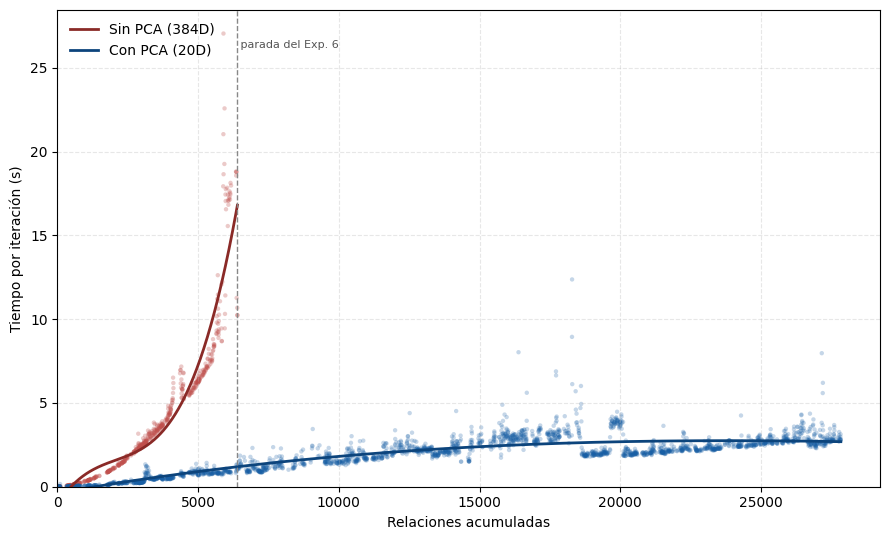

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar los dos dataframes de iteraciones y quedarse con las iteraciones con tiempo medido
pca = pd.read_pickle(
    f"../Output/experiments/df_resultados_iteraciones_exp16_pca_ortogonal_20260629_172044.pkl"
).dropna(subset=["tiempo_iteracion_segundos"]).sort_values("total_relaciones")

sin = pd.read_pickle(
    f"../Output/experiments/df_resultados_iteraciones_exp09_ortogonal_sinpca_20260628_191456.pkl"
).dropna(subset=["tiempo_iteracion_segundos"]).sort_values("total_relaciones")

# Punto en el que se detuvo el Experimento 6 (última relación procesada sin PCA)
parada_exp6 = int(sin["total_relaciones"].max())

# Curva de tendencia: ajuste polinómico de grado 3
def tendencia(x, y, deg=3):
    coef = np.polyfit(x, y, deg)
    xx = np.linspace(x.min(), x.max(), 300)
    return xx, np.polyval(coef, xx)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Nubes de puntos (tenues)
ax.scatter(sin["total_relaciones"], sin["tiempo_iteracion_segundos"],
           s=10, color="#c0504d", alpha=0.30, edgecolors="none")
ax.scatter(pca["total_relaciones"], pca["tiempo_iteracion_segundos"],
           s=10, color="#185FA5", alpha=0.25, edgecolors="none")

# Curvas de tendencia
xs, ys = tendencia(sin["total_relaciones"].to_numpy(),
                   sin["tiempo_iteracion_segundos"].to_numpy())
xp, yp = tendencia(pca["total_relaciones"].to_numpy(),
                   pca["tiempo_iteracion_segundos"].to_numpy())
ax.plot(xs, ys, color="#8a2a27", lw=2, label="Sin PCA (384D)")
ax.plot(xp, yp, color="#0C447C", lw=2, label="Con PCA (20D)")

# Marca de la parada del Experimento 6
ax.axvline(parada_exp6, color="#888", ls="--", lw=1)
ax.text(parada_exp6, ax.get_ylim()[1] * 0.92, " parada del Exp. 6",
        fontsize=8, color="#555")

ax.set_xlabel("Relaciones acumuladas")
ax.set_ylabel("Tiempo por iteración (s)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="upper left", frameon=False)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("exp7_coste_pca_vs_sinpca.png", dpi=300, bbox_inches="tight")
plt.savefig("exp7_coste_pca_vs_sinpca.svg", bbox_inches="tight")
plt.show()

Pasada de referencia: 2374 iteraciones, 27838 relaciones, 1154 clusters finales, ruido final 2.13%

umbral | iteración | % corpus | % clusters finales
  0.04  |     656 |   26.5% |   44.5%
  0.02  |     844 |   37.4% |   54.7%

Figura guardada en: calibracion_referencia_pca20.png


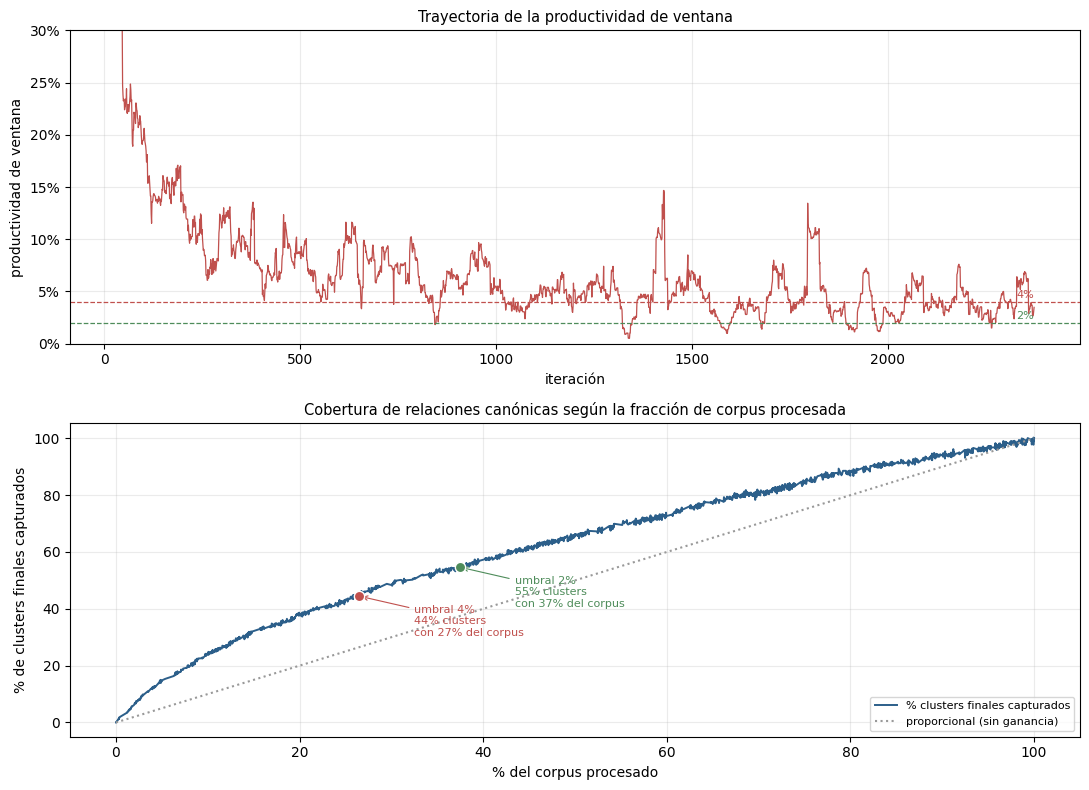

In [29]:
"""
Gráficas de calibración a partir del dataframe de resultados por iteración.

Gráficas:
  1) Trayectoria de la productividad de ventana a lo largo de las iteraciones,
     con las líneas de los umbrales candidatos.
  2) Curva de compromiso completitud-vs-cómputo: % de clusters finales
     capturados frente al % del corpus procesado, con los puntos de parada
     que provocaría cada umbral.

Uso en notebook (df ya en memoria o ruta al pickle):
    fig = generar_graficas_calibracion(df_resultados, umbrales=[0.04, 0.02])
    fig = generar_graficas_calibracion("df_resultados_iteraciones_....pkl")

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


def fmt_pct(u):
    """Formatea un umbral decimal como porcentaje: 0.04 -> '4%', 0.005 -> '0.5%'."""
    v = u * 100
    return f"{v:.0f}%" if v == int(v) else f"{v:.1f}%"
 
# ---------------------------------------------------------------------------
# Configuración
# ---------------------------------------------------------------------------
UMBRALES = [0.04, 0.02]            # umbrales de productividad a marcar
OUTPUT_PATH = "calibracion_referencia_pca20.png"   # imagen de salida (None = no guardar)
COLORES_UMBRAL = ["#c0504d", "#4e8c5a", "#8a6d3b", "#7a5c9e"]   # se reciclan
 
# Nombres de columna esperados en el dataframe de resultados
COL_ITER = "iteration"
COL_RELACIONES = "total_relaciones"
COL_CLUSTERS = "total_clusters"
COL_RUIDO_PCT = "noise_percentage"
COL_PRODUCTIVIDAD = "ratio_productividad_conocimiento_ventana"
 
 
# ---------------------------------------------------------------------------
# Cálculo del punto de parada que provocaría un umbral
# ---------------------------------------------------------------------------
def primer_cruce(df, umbral):
    """Primera iteración en que la productividad de ventana cae a <= umbral.
 
    Devuelve un dict con iteración, % de corpus procesado y % de clusters
    finales capturados en ese punto, o None si nunca cruza.
    """
    dv = df.dropna(subset=[COL_PRODUCTIVIDAD])
    cr = dv[dv[COL_PRODUCTIVIDAD] <= umbral]
    if len(cr) == 0:
        return None
    r = cr.iloc[0]
    final = df.iloc[-1]
    return {
        "umbral": umbral,
        "iteration": int(r[COL_ITER]),
        "pct_corpus": 100 * r[COL_RELACIONES] / final[COL_RELACIONES],
        "pct_clusters": 100 * r[COL_CLUSTERS] / final[COL_CLUSTERS],
    }
 
 
# ---------------------------------------------------------------------------
# Generación de las gráficas
# ---------------------------------------------------------------------------
def generar_graficas_calibracion(df, umbrales=UMBRALES,
                                 output_path=OUTPUT_PATH, mostrar_tabla=True):
    """`df` puede ser un DataFrame ya cargado o la ruta a un pickle."""
    if isinstance(df, str):
        df = pd.read_pickle(df)
    df = df.sort_values(COL_ITER).reset_index(drop=True)
 
    final = df.iloc[-1]
    Cf, Nf = final[COL_CLUSTERS], final[COL_RELACIONES]
    dv = df.dropna(subset=[COL_PRODUCTIVIDAD])
 
    cruces = [c for c in (primer_cruce(df, u) for u in umbrales) if c is not None]
 
    if mostrar_tabla:
        print(f"Pasada de referencia: {int(final[COL_ITER])} iteraciones, "
              f"{int(Nf)} relaciones, {int(Cf)} clusters finales, "
              f"ruido final {final[COL_RUIDO_PCT]}%\n")
        print("umbral | iteración | % corpus | % clusters finales")
        for c in cruces:
            print(f"  {c['umbral']:<5} |   {c['iteration']:>5} | "
                  f"{c['pct_corpus']:6.1f}% | {c['pct_clusters']:6.1f}%")
 
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))
 
    # --- Panel 1: productividad de ventana a lo largo de las iteraciones ---
    ax1.plot(dv[COL_ITER], dv[COL_PRODUCTIVIDAD] * 100, color="#c0504d", lw=0.9)
    for u, col in zip(umbrales, COLORES_UMBRAL):
        ax1.axhline(u * 100, ls="--", lw=0.9, color=col)
        ax1.text(dv[COL_ITER].max(), u * 100 + 0.4, fmt_pct(u),
                 color=col, fontsize=8, ha="right")
    ax1.set_ylabel("productividad de ventana")
    ax1.set_xlabel("iteración")
    ax1.set_ylim(0, max(30, dv[COL_PRODUCTIVIDAD].quantile(0.98) * 100))
    ax1.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax1.set_title("Trayectoria de la productividad de ventana", fontsize=10.5)
    ax1.grid(alpha=0.25)
 
    # --- Panel 2: completitud (% clusters finales) vs % corpus procesado ---
    pct_data = df[COL_RELACIONES] / Nf * 100
    pct_cl = df[COL_CLUSTERS] / Cf * 100
    ax2.plot(pct_data, pct_cl, color="#2c5f8a", lw=1.4,
             label="% clusters finales capturados")
    ax2.plot([0, 100], [0, 100], ls=":", color="#999",
             label="proporcional (sin ganancia)")
    for c, col in zip(cruces, COLORES_UMBRAL):
        x, y = c["pct_corpus"], c["pct_clusters"]
        ax2.scatter([x], [y], color=col, s=55, zorder=5, edgecolor="white")
        ax2.annotate(f"umbral {fmt_pct(c['umbral'])}\n{y:.0f}% clusters\n"
                     f"con {x:.0f}% del corpus",
                     xy=(x, y), xytext=(x + 6, y - 14), fontsize=8, color=col,
                     arrowprops=dict(arrowstyle="->", color=col, lw=0.8))
    ax2.set_xlabel("% del corpus procesado")
    ax2.set_ylabel("% de clusters finales capturados")
    ax2.set_title("Cobertura de relaciones canónicas según la fracción de corpus procesada", fontsize=10.5)
    ax2.legend(fontsize=8, loc="lower right")
    ax2.grid(alpha=0.25)
 
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=130, bbox_inches="tight")
        print(f"\nFigura guardada en: {output_path}")
    return fig


fig = generar_graficas_calibracion(df_resultados_iteraciones)
plt.show()

Figura guardada en: trayectoria_metricas.png  (4 paneles, mostrar='ambas')
Zona de formación: iter ≤96


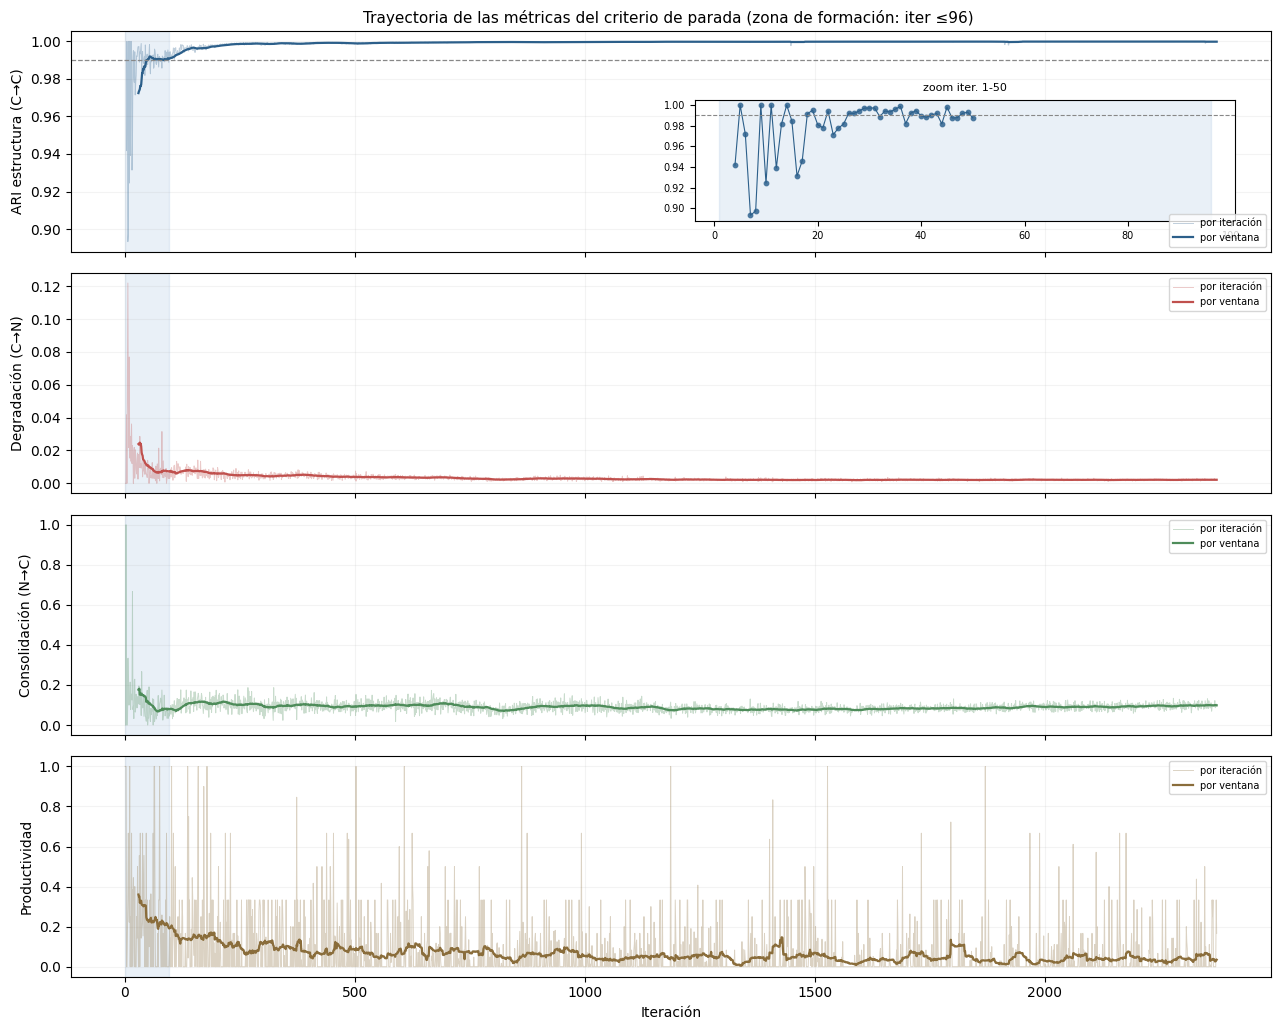

In [34]:
"""
Trayectoria de las métricas del criterio de parada, a partir del dataframe de
resultados por iteración.

Cada métrica existe en dos formas en el dataframe:
  - por ITERACIÓN: la señal cruda de cada paso.
  - por VENTANA  : la media móvil, que es la que usa la decisión de parada.

Por defecto se muestran ambas: la de iteración tenue y la de ventana gruesa.
Con `mostrar="ventana"` o `mostrar="iteracion"` se enseña solo una.

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Configuración
# ---------------------------------------------------------------------------
ARI_UMBRAL = 0.99          # umbral para delimitar la zona de formación
ZOOM_MAX = 50              # rango de iteraciones del recuadro de zoom (panel ARI)
DELTA_YLIM = (-3, 6)       # recorte vertical del panel de delta de clusters
OUTPUT_PATH = "trayectoria_metricas.png"   # imagen de salida (None = no guardar)

COL_ITER = "iteration"
C_ZONA = "#aac6e0"

# Especificación de las métricas a dibujar: (etiqueta, col_iteracion, col_ventana,
# tipo, color). col_ventana=None -> la métrica no tiene forma de ventana.
METRICAS = [
    ("ARI estructura (C→C)",  "ari_estructura",                     "media_ari_estructura",                     "linea",  "#2c5f8a"),
    ("Degradación (C→N)",     "tasa_degradacion",                   "media_tasa_degradacion",                   "linea",  "#c0504d"),
    ("Consolidación (N→C)",   "tasa_consolidacion",                 "media_tasa_consolidacion",                 "linea",  "#4e8c5a"),
    ("Productividad",         "ratio_conocimiento_nuevo_iteracion", "ratio_productividad_conocimiento_ventana", "linea",  "#8a6d3b"),
]


def _zona_formacion(df):
    bajo = df[df["ari_estructura"] < ARI_UMBRAL]
    return int(bajo[COL_ITER].max()) if len(bajo) else int(df[COL_ITER].min())


def _panel_linea(ax, df, col_iter, col_vent, color, mostrar):
    if mostrar in ("ambas", "iteracion") and col_iter in df:
        ax.plot(df[COL_ITER], df[col_iter], lw=0.7, color=color,
                alpha=0.30 if mostrar == "ambas" else 0.9,
                label="por iteración")
    if mostrar in ("ambas", "ventana") and col_vent and col_vent in df:
        ax.plot(df[COL_ITER], df[col_vent], lw=1.6, color=color,
                label="por ventana")
    if mostrar == "ambas" and col_vent:
        ax.legend(fontsize=7, loc="best")


def _panel_barras(ax, df, col_iter, color):
    d = df.dropna(subset=[col_iter])
    colores = np.where(d[col_iter] >= 0, color, "#b94a48")
    ax.bar(d[COL_ITER], d[col_iter], width=1.0, color=colores)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylim(*DELTA_YLIM)


def _zoom_ari(ax, df, fin_formacion, color):
    axz = ax.inset_axes([0.52, 0.14, 0.45, 0.55])
    dz = df[df[COL_ITER] <= ZOOM_MAX]
    axz.plot(dz[COL_ITER], dz["ari_estructura"], lw=0.8, color=color)
    axz.scatter(dz[COL_ITER], dz["ari_estructura"], s=10, color=color)
    axz.axhline(ARI_UMBRAL, ls="--", lw=0.8, color="#888")
    axz.axvspan(dz[COL_ITER].min(), fin_formacion, color=C_ZONA, alpha=0.25)
    axz.set_title(f"zoom iter. 1-{ZOOM_MAX}", fontsize=8)
    axz.tick_params(labelsize=7)


def graficar_trayectoria_metricas(df, mostrar="ambas", output_path=OUTPUT_PATH,
                                  metricas=METRICAS):

    df = df.sort_values(COL_ITER).reset_index(drop=True)
    fin_formacion = _zona_formacion(df)

    metricas = [m for m in metricas if m[1] in df.columns]
    n = len(metricas)
    fig, axes = plt.subplots(n, 1, figsize=(13, 2.6 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, (etq, col_it, col_vt, tipo, color) in zip(axes, metricas):
        if tipo == "barras":
            _panel_barras(ax, df, col_it, color)
            ax.text(df[COL_ITER].max() * 0.45, DELTA_YLIM[1] * 0.78,
                    "rojo = Δ negativo (fusión neta): clusters marginales,\n"
                    "no reorganización (el ARI sigue ≈1)",
                    fontsize=7.5, color="#555", ha="left", va="top",
                    bbox=dict(boxstyle="round", fc="white", ec="none", alpha=0.75))
        else:
            _panel_linea(ax, df, col_it, col_vt, color, mostrar)
            if col_it == "ari_estructura":
                ax.axhline(ARI_UMBRAL, ls="--", lw=0.9, color="#888")
                _zoom_ari(ax, df, fin_formacion, color)
        ax.axvspan(df[COL_ITER].min(), fin_formacion, color=C_ZONA, alpha=0.25)
        ax.set_ylabel(etq)
        ax.grid(alpha=0.15)

    axes[0].set_title("Trayectoria de las métricas del criterio de parada "
                      f"(zona de formación: iter ≤{fin_formacion}) ", fontsize=11)
    axes[-1].set_xlabel("Iteración")
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=130, bbox_inches="tight")
        print(f"Figura guardada en: {output_path}  ({n} paneles, mostrar='{mostrar}')")
        print(f"Zona de formación: iter ≤{fin_formacion}")
    return fig


fig = graficar_trayectoria_metricas(df_resultados_iteraciones)
plt.show()


Figura guardada en: evolucion_conocimiento.png
Final: 27838 relaciones extraídas -> KG de 1748 (1154 canónicas + 594 ruido); compresión 15.9x


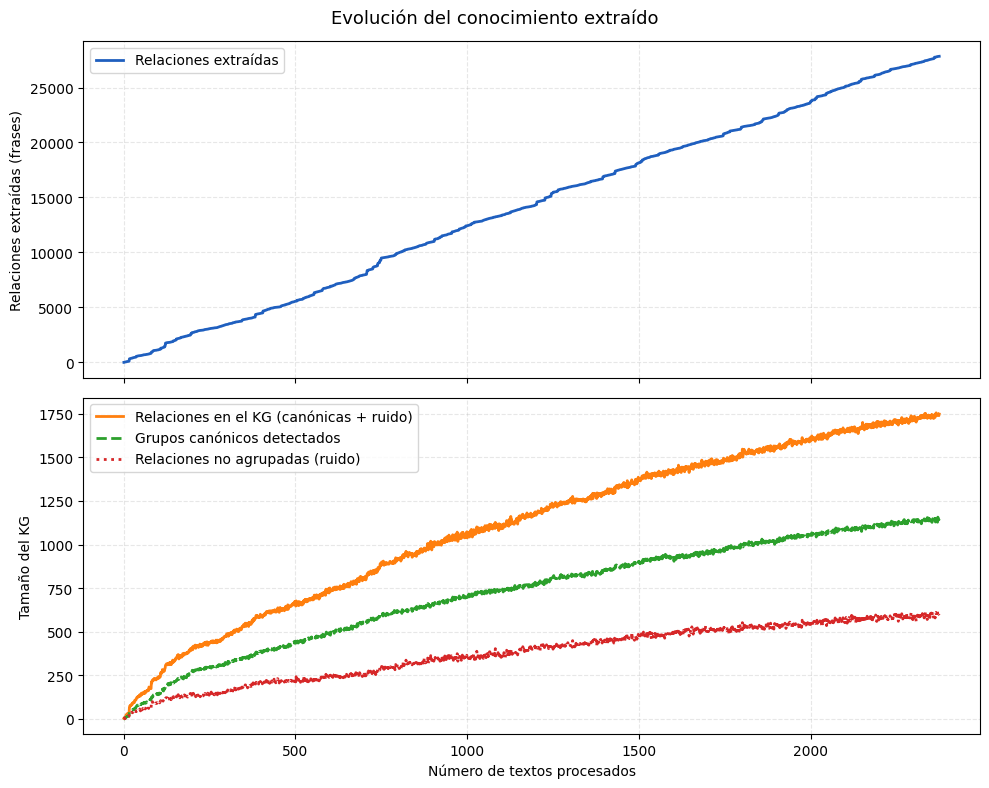

In [42]:
"""
Evolución del conocimiento extraído.
  - Panel superior: relaciones (frases) extraídas acumuladas.
  - Panel inferior: tamaño del KG = grupos canónicos + ruido.


"""

import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_PATH = "evolucion_conocimiento.png"


def graficar_evolucion_conocimiento(df, output_path=OUTPUT_PATH):

    df = df.sort_values("iteration").reset_index(drop=True)
    x = df["iteration"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # --- Panel superior: relaciones extraídas ---
    ax1.plot(x, df["total_relaciones"], lw=2, color="#1f5fbf",
             label="Relaciones extraídas")
    ax1.set_ylabel("Relaciones extraídas (frases)")
    ax1.legend(loc="upper left")
    ax1.grid(True, linestyle="--", alpha=0.3)

    # --- Panel inferior: tamaño del KG (canónicas + ruido) ---
    ax2.plot(x, df["total_relaciones_kg"], lw=2, color="#ff7f0e",
             label="Relaciones en el KG (canónicas + ruido)")
    ax2.plot(x, df["total_clusters"], lw=2, ls="--", color="#2ca02c",
             label="Grupos canónicos detectados")
    ax2.plot(x, df["total_noise"], lw=2, ls=":", color="#d62728",
             label="Relaciones no agrupadas (ruido)")
    ax2.set_ylabel("Tamaño del KG")
    ax2.set_xlabel("Número de textos procesados")
    ax2.legend(loc="upper left")
    ax2.grid(True, linestyle="--", alpha=0.3)

    fig.suptitle("Evolución del conocimiento extraído", fontsize=13)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        fin = df.iloc[-1]
        print(f"Figura guardada en: {output_path}")
        print(f"Final: {int(fin['total_relaciones'])} relaciones extraídas -> "
              f"KG de {int(fin['total_relaciones_kg'])} "
              f"({int(fin['total_clusters'])} canónicas + "
              f"{int(fin['total_noise'])} ruido); "
              f"compresión {fin['total_relaciones']/fin['total_relaciones_kg']:.1f}x")
    plt.close(fig)
    return fig



graficar_evolucion_conocimiento(df_resultados_iteraciones)

